In [41]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# Reading the file
data = pd.read_csv(
    "SMSSpamCollection (2)",
    sep="\t",
    names=["label", "message"]
)

data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [45]:
#Info
print("Shape of Dataset:")
print(data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nInformation:")
print(data.info())

Shape of Dataset:
(5572, 2)

Column Names:
Index(['label', 'message'], dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [47]:
#Checking missing values
print(data.isnull().sum())

label      0
message    0
dtype: int64


In [49]:
print(data["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


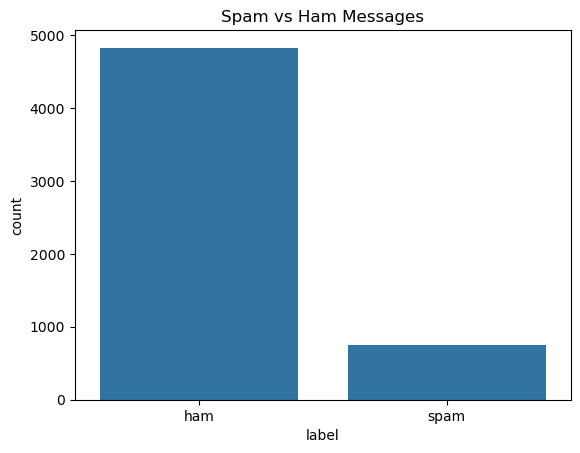

In [51]:
#Visualization
sns.countplot(x="label",data=data)
plt.title("Spam vs Ham Messages")
plt.show()

In [53]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [55]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mayan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mayan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [57]:
# creating a Preprocessing function
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
# Tokenize
    words = word_tokenize(text)
# Remove punctuation and stopwords
    words = [ word for word in words 
         if word not in stop_words and word not in string.punctuation 
        ]

# Join words back into a sentence
    return " ".join(words)

In [59]:
# Apply Preprocessing
data["message"] = data["message"].apply(preprocess_text)

In [60]:
# Copntinue with TF-IDF
x = data["message"]
y = data["label"]

vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(x)

In [61]:
##Labels -> numbers
data["label"] = data["label"].map({"ham":0,"spam":1})
print(data.head())

   label                                            message
0      0  go jurong point crazy .. available bugis n gre...
1      0                    ok lar ... joking wif u oni ...
2      1  free entry 2 wkly comp win fa cup final tkts 2...
3      0        u dun say early hor ... u c already say ...
4      0         nah n't think goes usf lives around though


In [62]:
#Separating features and target

x = data["message"]
y = data["label"]

In [67]:
# text -> Numbers
vectorizer = TfidfVectorizer()

x = vectorizer.fit_transform(x)

print("Shape after TF-IDF:")
print(x.shape)

Shape after TF-IDF:
(5572, 8645)


In [69]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
#Train Model
model = MultinomialNB()
model.fit(x_train , y_train)
print("Model Training Completed")

Model Training Completed


In [73]:
# Making predictions 
predictions = model.predict(x_test)
print(predictions)

[0 0 0 ... 0 0 0]


In [75]:
#Accuracy Score
accuracy = accuracy_score(y_test , predictions)
print("Accuracy = " , accuracy * 100 , "%")

Accuracy =  96.95067264573991 %


In [77]:
#Confusion Matrix
cm = confusion_matrix(y_test , predictions)
cm

array([[966,   0],
       [ 34, 115]], dtype=int64)

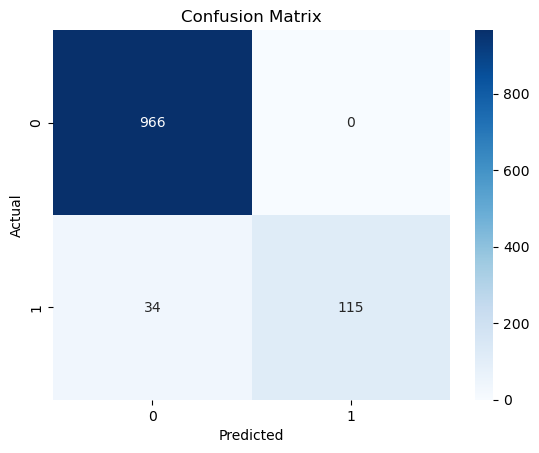

In [79]:
#Visualize Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [81]:
#Classification report 
print(classification_report(y_test , predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [83]:
message = [
    "Congratulations you have won a free iPhone"
]

message_vector = vectorizer.transform(message)

result = model.predict(message_vector)

if result[0] == 1:
    print("Spam Mail")
else:
    print("Ham Mail")

Ham Mail


In [85]:
messages = [

    "Meeting at 5 PM today",

    "Win cash prize now",

    "Submit your assignment tomorrow",

    "Claim your free gift voucher"

]

messages_vector = vectorizer.transform(messages)

results = model.predict(messages_vector)

for msg,res in zip(messages,results):

    print("Message:",msg)

    if res == 1:
        print("Prediction: Spam")
    else:
        print("Prediction: Ham")

    print()

Message: Meeting at 5 PM today
Prediction: Ham

Message: Win cash prize now
Prediction: Spam

Message: Submit your assignment tomorrow
Prediction: Ham

Message: Claim your free gift voucher
Prediction: Spam



In [87]:
from sklearn.linear_model import LogisticRegression

# Model
lr_model = LogisticRegression()

lr_model.fit(x_train , y_train)

lr_predictions = lr_model.predict(x_test)
print("Logistic Regression Accuracy : ")
print(accuracy_score(y_test , lr_predictions))

Logistic Regression Accuracy : 
0.957847533632287


In [89]:
print("Naive Bayes Accuracy : ")
print(accuracy_score(y_test , predictions))

Naive Bayes Accuracy : 
0.9695067264573991
